# Comparación de Modelos: Multinomial Naive Bayes vs Logistic Regression vs BERT

Este notebook implementa y compara tres modelos para clasificar negative reasons en tweets:

1. **Multinomial Naive Bayes** con TF-IDF
2. **Logistic Regression** con TF-IDF  
3. **BERT** (implementado en training.ipynb)

**Pipeline para modelos tradicionales:**
- Mismo preprocesamiento que BERT (mínimo)
- TF-IDF Vectorization
- SMOTE para balanceo de clases
- Entrenamiento y evaluación
- Comparación con métricas y gráficos

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


In [18]:
data = pd.read_csv('../data/Tweets.csv')

In [19]:
df = data.copy()

## 1. Preparación de Datos

In [20]:
# Preparar los datos usando el MISMO preprocesamiento que BERT
# Filtrar tweets negativos con negativereason válido (sin "Can't Tell")
df = data[(data['airline_sentiment'] == 'negative') & 
          (data['negativereason'].notna())].copy()

# Remover "Can't Tell" si aún existe
df = df[df['negativereason'] != "Can't Tell"]

# IMPORTANTE: Aplicar la misma consolidación que en training.ipynb
# Consolidar "Damaged Luggage" y "Lost Luggage" en "Luggage Problems"
df['negativereason'] = df['negativereason'].replace({
    'Damaged Luggage': 'Luggage Problems',
    'Lost Luggage': 'Luggage Problems'
})

print(f"Número total de tweets: {len(df)}")
print(f"Distribución de clases (DESPUÉS de consolidación):")
print(df['negativereason'].value_counts())

# Preprocesamiento MÍNIMO (igual que BERT)
# Solo remover URLs y reemplazar mentions (sin stopwords, sin lemmatización)
df['text_clean'] = df['text'].str.replace(r'http\S+', '', regex=True)  # Solo URLs
df['text_clean'] = df['text_clean'].str.replace(r'@\w+', '@user', regex=True)  # Mentions

# Codificar etiquetas
label_encoder = LabelEncoder()
df['labels'] = label_encoder.fit_transform(df['negativereason'])

# Crear mapeos
label_to_id = {label: idx for idx, label in enumerate(label_encoder.classes_)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

print(f"\nMapeo de etiquetas:")
for label, idx in label_to_id.items():
    print(f"  {idx}: {label}")

print(f"\nPrimeros 3 ejemplos:")
for i, (text, label) in enumerate(zip(df['text_clean'].head(3), df['negativereason'].head(3))):
    print(f"{i+1}. [{label}] {text[:80]}...")

Número total de tweets: 7988
Distribución de clases (DESPUÉS de consolidación):
negativereason
Customer Service Issue         2910
Late Flight                    1665
Cancelled Flight                847
Luggage Problems                798
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Name: count, dtype: int64

Mapeo de etiquetas:
  0: Bad Flight
  1: Cancelled Flight
  2: Customer Service Issue
  3: Flight Attendant Complaints
  4: Flight Booking Problems
  5: Late Flight
  6: Luggage Problems
  7: longlines

Primeros 3 ejemplos:
1. [Bad Flight] @user it's really aggressive to blast obnoxious "entertainment" in your guests' ...
2. [Late Flight] @user SFO-PDX schedule is still MIA....
3. [Bad Flight] @user  I flew from NYC to SFO last week and couldn't fully sit in my seat due to...


## 2. División de Datos y TF-IDF Vectorization

In [21]:
# División de datos (igual que BERT: 80% train, 20% test, luego 80% train, 20% val)
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'], 
    df['labels'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['labels']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

print(f"Tamaños de conjuntos:")
print(f"- Entrenamiento: {len(X_train)}")
print(f"- Validación: {len(X_val)}")
print(f"- Prueba: {len(X_test)}")

print(f"\nDistribución ANTES de SMOTE:")
print(f"Entrenamiento: {Counter(y_train)}")

# TF-IDF Vectorization
print(f"\n🔄 Aplicando TF-IDF Vectorization...")
tfidf = TfidfVectorizer(
    max_features=5000,        # Limitar características para eficiencia
    min_df=2,                 # Mínimo 2 documentos para incluir término
    max_df=0.95,              # Máximo 95% de documentos
    ngram_range=(1, 2),       # Unigrams y bigrams
    lowercase=True,
    stop_words='english'      # Para TF-IDF sí usamos stopwords
)

# Entrenar TF-IDF solo en conjunto de entrenamiento
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Dimensiones TF-IDF:")
print(f"- Entrenamiento: {X_train_tfidf.shape}")
print(f"- Validación: {X_val_tfidf.shape}")
print(f"- Prueba: {X_test_tfidf.shape}")

# Aplicar SMOTE para balancear clases
print(f"\n🎯 Aplicando SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=3)  # k_neighbors=3 por clases pequeñas
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

print(f"Distribución DESPUÉS de SMOTE:")
print(f"Entrenamiento: {Counter(y_train_balanced)}")
print(f"Tamaño después de SMOTE: {X_train_balanced.shape[0]}")
print(f"Incremento: {X_train_balanced.shape[0] - X_train_tfidf.shape[0]} muestras")

Tamaños de conjuntos:
- Entrenamiento: 5112
- Validación: 1278
- Prueba: 1598

Distribución ANTES de SMOTE:
Entrenamiento: Counter({2: 1863, 5: 1066, 1: 542, 6: 510, 0: 371, 4: 338, 3: 308, 7: 114})

🔄 Aplicando TF-IDF Vectorization...
Dimensiones TF-IDF:
- Entrenamiento: (5112, 5000)
- Validación: (1278, 5000)
- Prueba: (1598, 5000)

🎯 Aplicando SMOTE...
Distribución DESPUÉS de SMOTE:
Entrenamiento: Counter({1: 1863, 5: 1863, 6: 1863, 2: 1863, 0: 1863, 4: 1863, 7: 1863, 3: 1863})
Tamaño después de SMOTE: 14904
Incremento: 9792 muestras
Dimensiones TF-IDF:
- Entrenamiento: (5112, 5000)
- Validación: (1278, 5000)
- Prueba: (1598, 5000)

🎯 Aplicando SMOTE...
Distribución DESPUÉS de SMOTE:
Entrenamiento: Counter({1: 1863, 5: 1863, 6: 1863, 2: 1863, 0: 1863, 4: 1863, 7: 1863, 3: 1863})
Tamaño después de SMOTE: 14904
Incremento: 9792 muestras


## 3. Entrenamiento de modelos

### 3.1 Multinomial Naive Bayes

In [22]:
print("🚀 Entrenando Multinomial Naive Bayes...")

nb_model = MultinomialNB(alpha=1.0)  # Laplace smoothing
nb_model.fit(X_train_balanced, y_train_balanced)

# Predicciones
nb_val_pred = nb_model.predict(X_val_tfidf)
nb_test_pred = nb_model.predict(X_test_tfidf)

# Métricas
nb_val_acc = accuracy_score(y_val, nb_val_pred)
nb_test_acc = accuracy_score(y_test, nb_test_pred)
nb_precision, nb_recall, nb_f1, _ = precision_recall_fscore_support(y_test, nb_test_pred, average='weighted')

print(f"✅ Naive Bayes completado:")
print(f"- Accuracy validación: {nb_val_acc:.4f}")
print(f"- Accuracy test: {nb_test_acc:.4f}")
print(f"- F1-score test: {nb_f1:.4f}")


🚀 Entrenando Multinomial Naive Bayes...
✅ Naive Bayes completado:
- Accuracy validación: 0.6088
- Accuracy test: 0.5720
- F1-score test: 0.5887


## 3.2 Logistic Regression

In [23]:
print(f"\n🚀 Entrenando Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  # Ayuda con desbalance residual
    C=1.0                     # Regularización
)
lr_model.fit(X_train_balanced, y_train_balanced)

# Predicciones
lr_val_pred = lr_model.predict(X_val_tfidf)
lr_test_pred = lr_model.predict(X_test_tfidf)

# Métricas
lr_val_acc = accuracy_score(y_val, lr_val_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)
lr_precision, lr_recall, lr_f1, _ = precision_recall_fscore_support(y_test, lr_test_pred, average='weighted')

print(f"✅ Logistic Regression completado:")
print(f"- Accuracy validación: {lr_val_acc:.4f}")
print(f"- Accuracy test: {lr_test_acc:.4f}")
print(f"- F1-score test: {lr_f1:.4f}")

print(f"\n📊 Resumen de resultados:")
print(f"{'Modelo':<20} {'Acc Val':<10} {'Acc Test':<10} {'F1 Test':<10}")
print(f"{'='*50}")
print(f"{'Naive Bayes':<20} {nb_val_acc:<10.4f} {nb_test_acc:<10.4f} {nb_f1:<10.4f}")
print(f"{'Logistic Reg':<20} {lr_val_acc:<10.4f} {lr_test_acc:<10.4f} {lr_f1:<10.4f}")
# print(f"{'BERT (ref)*':<20} {'TBD':<10} {'TBD':<10} {'TBD':<10}")
# print(f"* Ejecutar training.ipynb para obtener métricas de BERT")


🚀 Entrenando Logistic Regression...
✅ Logistic Regression completado:
- Accuracy validación: 0.6682
- Accuracy test: 0.6427
- F1-score test: 0.6543

📊 Resumen de resultados:
Modelo               Acc Val    Acc Test   F1 Test   
Naive Bayes          0.6088     0.5720     0.5887    
Logistic Reg         0.6682     0.6427     0.6543    
✅ Logistic Regression completado:
- Accuracy validación: 0.6682
- Accuracy test: 0.6427
- F1-score test: 0.6543

📊 Resumen de resultados:
Modelo               Acc Val    Acc Test   F1 Test   
Naive Bayes          0.6088     0.5720     0.5887    
Logistic Reg         0.6682     0.6427     0.6543    


## 4. Evaluación y Visualizaciones

### 4.1 Matrices de Confusión

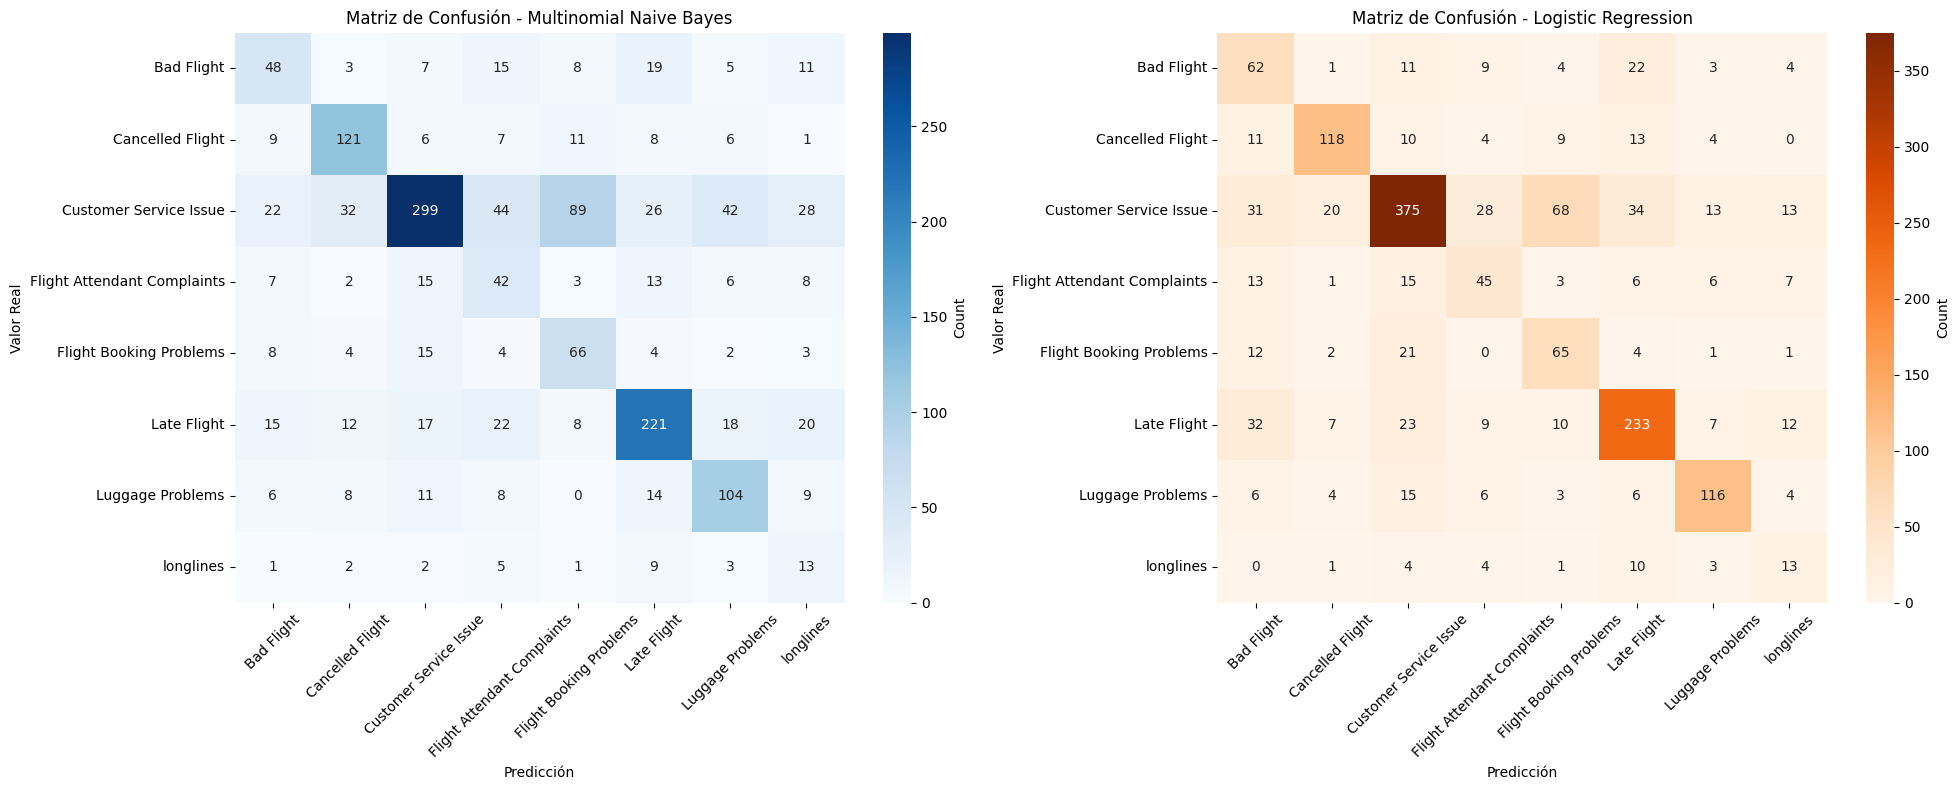

In [24]:
target_names = [id_to_label[i] for i in range(len(label_encoder.classes_))]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz de confusión - Naive Bayes
nb_cm = confusion_matrix(y_test, nb_test_pred)
nb_cm_df = pd.DataFrame(nb_cm, index=target_names, columns=target_names)

sns.heatmap(nb_cm_df, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Matriz de Confusión - Multinomial Naive Bayes')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')
axes[0].tick_params(axis='x', rotation=45)

# Matriz de confusión - Logistic Regression
lr_cm = confusion_matrix(y_test, lr_test_pred)
lr_cm_df = pd.DataFrame(lr_cm, index=target_names, columns=target_names)

sns.heatmap(lr_cm_df, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Matriz de Confusión - Logistic Regression')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

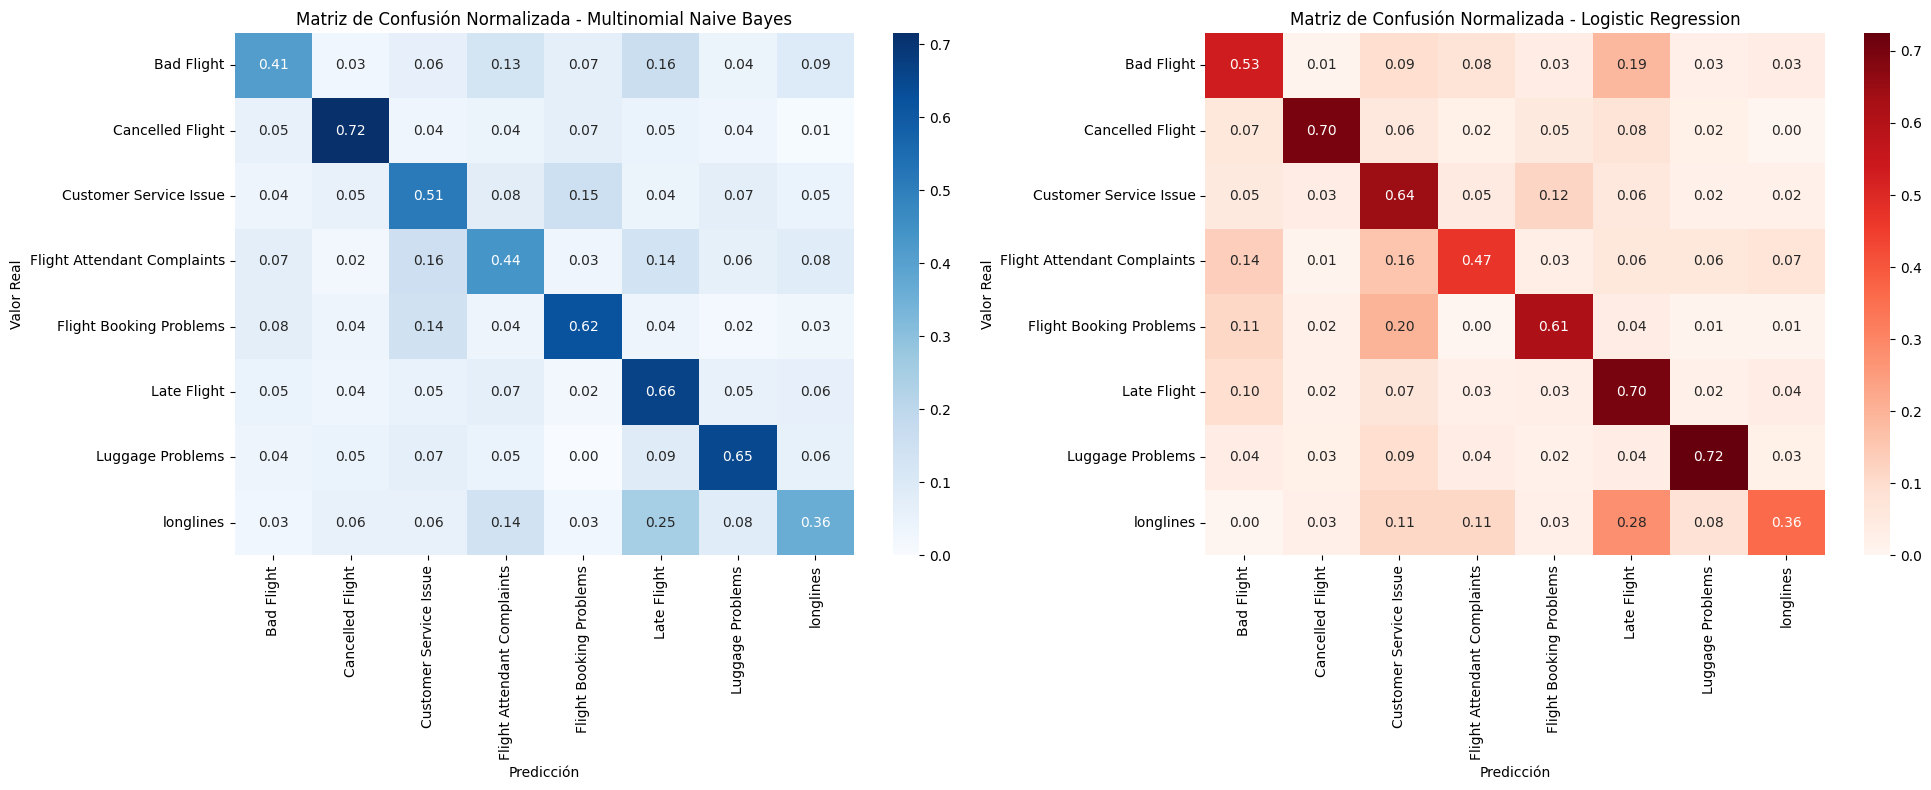

In [29]:
nb_cm_norm = confusion_matrix(y_test, nb_test_pred, normalize='true')
lr_cm_norm = confusion_matrix(y_test, lr_test_pred, normalize='true')

nb_cm_norm_df = pd.DataFrame(nb_cm_norm, index=target_names, columns=target_names)
lr_cm_norm_df = pd.DataFrame(lr_cm_norm, index=target_names, columns=target_names)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(nb_cm_norm_df, annot=True, fmt='.2f', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión Normalizada - Multinomial Naive Bayes')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')


sns.heatmap(lr_cm_norm_df, annot=True, fmt='.2f', cmap='Reds', ax=axes[1])
axes[1].set_title('Matriz de Confusión Normalizada - Logistic Regression')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# Descomentar si se desea mas detallado de las matrices de confusión normalizadas
# print("Normalized Confusion Matrix - Multinomial Naive Bayes:")
# print(nb_cm_norm_df.round(3))
# print("\nNormalized Confusion Matrix - Logistic Regression:")
# print(lr_cm_norm_df.round(3))

### 4.2 Reportes de Clasificación

In [25]:
print("📋 REPORTE DETALLADO - MULTINOMIAL NAIVE BAYES")
print("="*60)
print(classification_report(y_test, nb_test_pred, target_names=target_names))

print("\n📋 REPORTE DETALLADO - LOGISTIC REGRESSION")
print("="*60)
print(classification_report(y_test, lr_test_pred, target_names=target_names))

📋 REPORTE DETALLADO - MULTINOMIAL NAIVE BAYES
                             precision    recall  f1-score   support

                 Bad Flight       0.41      0.41      0.41       116
           Cancelled Flight       0.66      0.72      0.69       169
     Customer Service Issue       0.80      0.51      0.63       582
Flight Attendant Complaints       0.29      0.44      0.35        96
    Flight Booking Problems       0.35      0.62      0.45       106
                Late Flight       0.70      0.66      0.68       333
           Luggage Problems       0.56      0.65      0.60       160
                  longlines       0.14      0.36      0.20        36

                   accuracy                           0.57      1598
                  macro avg       0.49      0.55      0.50      1598
               weighted avg       0.64      0.57      0.59      1598


📋 REPORTE DETALLADO - LOGISTIC REGRESSION
                             precision    recall  f1-score   support

          

### 4.3 Comparación Visual de Métricas

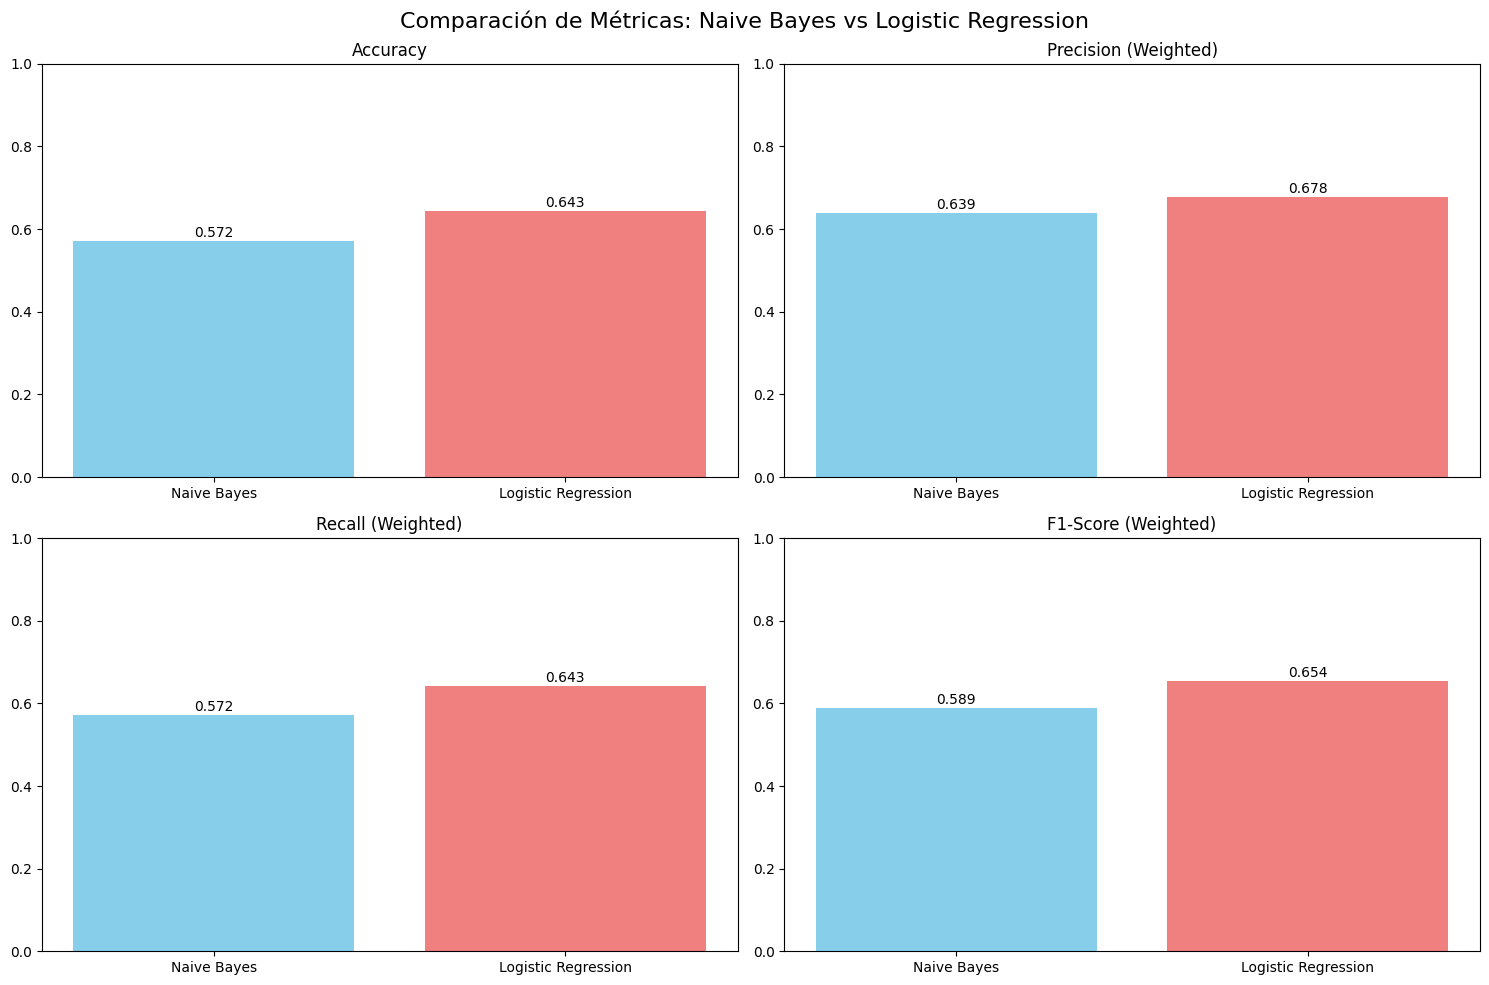


📊 TABLA RESUMEN DE MÉTRICAS
                Modelo  Accuracy  Precision  Recall  F1-Score
0          Naive Bayes    0.5720     0.6388  0.5720    0.5887
1  Logistic Regression    0.6427     0.6777  0.6427    0.6543


In [26]:
metrics_data = {
    'Modelo': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_test_acc, lr_test_acc],
    'Precision': [nb_precision, lr_precision],
    'Recall': [nb_recall, lr_recall],
    'F1-Score': [nb_f1, lr_f1]
}

metrics_df = pd.DataFrame(metrics_data)

# Gráfico de barras para métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparación de Métricas: Naive Bayes vs Logistic Regression', fontsize=16)

# Accuracy
axes[0,0].bar(metrics_df['Modelo'], metrics_df['Accuracy'], color=['skyblue', 'lightcoral'])
axes[0,0].set_title('Accuracy')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(metrics_df['Accuracy']):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Precision
axes[0,1].bar(metrics_df['Modelo'], metrics_df['Precision'], color=['skyblue', 'lightcoral'])
axes[0,1].set_title('Precision (Weighted)')
axes[0,1].set_ylim(0, 1)
for i, v in enumerate(metrics_df['Precision']):
    axes[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Recall
axes[1,0].bar(metrics_df['Modelo'], metrics_df['Recall'], color=['skyblue', 'lightcoral'])
axes[1,0].set_title('Recall (Weighted)')
axes[1,0].set_ylim(0, 1)
for i, v in enumerate(metrics_df['Recall']):
    axes[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# F1-Score
axes[1,1].bar(metrics_df['Modelo'], metrics_df['F1-Score'], color=['skyblue', 'lightcoral'])
axes[1,1].set_title('F1-Score (Weighted)')
axes[1,1].set_ylim(0, 1)
for i, v in enumerate(metrics_df['F1-Score']):
    axes[1,1].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n📊 TABLA RESUMEN DE MÉTRICAS")
print("="*50)
print(metrics_df.round(4))

### 4.4 Análisis de Errores 

In [27]:
print("🔍 ANÁLISIS DE ERRORES")
print("="*50)

# Naive Bayes errors
nb_errors = np.where(nb_test_pred != y_test)[0]
print(f"Naive Bayes - Errores: {len(nb_errors)}/{len(y_test)} ({len(nb_errors)/len(y_test)*100:.1f}%)")

if len(nb_errors) > 0:
    print(f"\n📝 Ejemplos de errores - Naive Bayes (primeros 5):")
    for i, idx in enumerate(nb_errors[:5]):
        actual = id_to_label[y_test.iloc[idx]]
        predicted = id_to_label[nb_test_pred[idx]]
        text = X_test.iloc[idx]
        print(f"{i+1}. TEXTO: {text[:80]}...")
        print(f"   REAL: {actual} | PREDICHO: {predicted}\n")

# Logistic Regression errors
lr_errors = np.where(lr_test_pred != y_test)[0]
print(f"Logistic Regression - Errores: {len(lr_errors)}/{len(y_test)} ({len(lr_errors)/len(y_test)*100:.1f}%)")

if len(lr_errors) > 0:
    print(f"\n📝 Ejemplos de errores - Logistic Regression (primeros 5):")
    for i, idx in enumerate(lr_errors[:5]):
        actual = id_to_label[y_test.iloc[idx]]
        predicted = id_to_label[lr_test_pred[idx]]
        text = X_test.iloc[idx]
        print(f"{i+1}. TEXTO: {text[:80]}...")
        print(f"   REAL: {actual} | PREDICHO: {predicted}\n")

🔍 ANÁLISIS DE ERRORES
Naive Bayes - Errores: 684/1598 (42.8%)

📝 Ejemplos de errores - Naive Bayes (primeros 5):
1. TEXTO: @user @user use the app you say?? ...
   REAL: Customer Service Issue | PREDICHO: Flight Booking Problems

2. TEXTO: @user ok makes no sense tho Since you'll give me a free upgrade to first....
   REAL: Bad Flight | PREDICHO: Late Flight

3. TEXTO: @user   Yes. Dale at Baggage office was wonderful. But not everyone is on the sa...
   REAL: Late Flight | PREDICHO: longlines

4. TEXTO: @user I'm trying to get to my final destination, we need compensation. Just abou...
   REAL: Late Flight | PREDICHO: Flight Booking Problems

5. TEXTO: @user I wrote to you but got nothing.and I am out of US .It is very simple thing...
   REAL: Late Flight | PREDICHO: Customer Service Issue

Logistic Regression - Errores: 571/1598 (35.7%)

📝 Ejemplos de errores - Logistic Regression (primeros 5):
1. TEXTO: @user ok makes no sense tho Since you'll give me a free upgrade to first....
   

## 5. Conclusiones y Siguientes Pasos

### 📊 Resultados Obtenidos

Los modelos tradicionales con TF-IDF han sido entrenados usando:
- **Mismo preprocesamiento que BERT**: Solo remoción de URLs y mentions
- **TF-IDF Vectorization**: Con unigrams y bigrams (max_features=5000)
- **SMOTE**: Para balancear las clases automáticamente
- **Misma división de datos**: Train/Val/Test consistente

### 🎯 Próximos Pasos

1. **Ejecutar `training.ipynb`** para obtener métricas de BERT
2. **Comparar los tres modelos** en el mismo formato
3. **Decidir modelo final** basado en:
   - F1-Score (métrica principal)
   - Tiempo de inferencia
   - Interpretabilidad
   - Recursos computacionales

### 💡 Ventajas de cada modelo:

- **Naive Bayes**: Rápido, interpretable, bueno con texto
- **Logistic Regression**: Balance entre simplicidad y rendimiento
- **BERT**: Mayor capacidad de capturar semántica compleja

### 🔄 Para completar la comparación:
```python
# Ejecutar training.ipynb y luego agregar métricas aquí:
bert_metrics = {
    'accuracy': 0.XXXX,  # Del training.ipynb
    'f1': 0.XXXX,        # Del training.ipynb
    'precision': 0.XXXX, # Del training.ipynb
    'recall': 0.XXXX     # Del training.ipynb
}
```